In [8]:
#OUTLIER HANDLING

In [ ]:
# Phase 1: Data Loading and Outlier Detection
#**Objective:** Load the raw `student_performance.csv` dataset and visually inspect it for anomalies before applying machine learning algorithms. 

#In this section, we import necessary visualization libraries (`seaborn`, `matplotlib`) and generate a Boxplot for our target feature. 
#The boxplot allows us to visually identify any extreme outliers (e.g., impossible study hours) that fall outside the typical distribution, 
#which could negatively skew our model's predictions.

In [2]:
import micropip
await micropip.install('seaborn')
import seaborn as sns

print("Seaborn is installed and ready!")

Seaborn is installed and ready!


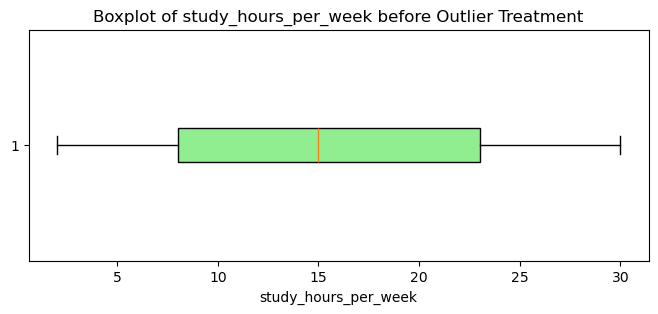

In [2]:
#LOADING AND INSPECTING THE DATA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Load the dataset
df = pd.read_csv('student_performance.csv')

# 2. Define the target column
target_col = 'study_hours_per_week'

# 3. Visually inspect the outliers
plt.figure(figsize=(8, 3))
plt.boxplot(df[target_col].dropna(), vert=False, patch_artist=True, 
            boxprops=dict(facecolor='lightgreen'))
plt.title(f'Boxplot of {target_col} before Outlier Treatment')
plt.xlabel(target_col)
plt.show()

In [37]:
#The orange line inside the green box is the median. It represents the middle value of the dataset. 
#In this chart, the median is exactly 15 hours. 
#This means that 50% of the students study less than 15 hours, and 50% study more.

#--The green box represents the middle 50% of your data.--

#The Left Edge ,This is at roughly 8 hours. 25% of students study less than this.

#The Right Edge , This is at roughly 23 hours. 75% of students study less than this.

#The Box Width: The distance between these two edges is the Interquartile Range (IQR). It shows where the "typical" study habits lie.

#--The lines extending from the box are called whiskers. They show the overall range of the data, excluding outliers.--

#Minimum study hours: Around 2 hours.

#Maximum study hours: Around 30 hours.

In [3]:
df.head()

,student_id,gender,age,study_hours_per_week,attendance_rate,parent_education,internet_access,extracurricular,previous_score,final_score,passed
0,STU0001,Male,15,25,63.8,Bachelor,Yes,Yes,41,67,Yes
1,STU0002,Female,15,2,54.7,Bachelor,Yes,Yes,83,28,No
2,STU0003,Female,19,10,90.5,High School,Yes,No,73,49,No
3,STU0004,Male,16,26,66.8,High School,No,Yes,75,70,Yes
4,STU0005,Female,15,25,73.0,High School,No,Yes,67,77,Yes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   student_id            500 non-null    object 
 1   gender                500 non-null    object 
 2   age                   500 non-null    int64  
 3   study_hours_per_week  500 non-null    int64  
 4   attendance_rate       500 non-null    float64
 5   parent_education      383 non-null    object 
 6   internet_access       500 non-null    object 
 7   extracurricular       500 non-null    object 
 8   previous_score        500 non-null    int64  
 9   final_score           500 non-null    int64  
 10  passed                500 non-null    object 
dtypes: float64(1), int64(4), object(6)
memory usage: 31.3+ KB


In [ ]:
## Statistical Outlier Treatment (IQR Method)
#To handle outliers mathematically rather than just visually, we calculate the **Interquartile Range (IQR)**. 
#1. We determine the 25th (Q1) and 75th (Q3) percentiles to find the middle 50% of our data.
#2. We establish strict upper and lower statistical boundaries.
#3. **Imputation:** Instead of dropping rows with outlier values (which results in data loss), 
#we cap them by replacing the extreme values with the mean of the normal distribution. 
#This preserves our dataset's size while smoothing out anomalies.

In [5]:
# 1. Calculate the 25th percentile (Q1) and 75th percentile (Q3)
q25 = np.percentile(df[target_col].dropna(), 25)
q75 = np.percentile(df[target_col].dropna(), 75)

# 2. Calculate the Interquartile Range (IQR)
iqr = q75 - q25

# 3. Define the statistical lower and upper bounds
lower_limit = max(0, q25 - 1.5 * iqr)
upper_limit = q75 + 1.5 * iqr

print(f"Statistically normal range: {lower_limit} to {upper_limit}")

# 4. Show the isolated outlier rows
outliers = df[(df[target_col] < lower_limit) | (df[target_col] > upper_limit)]
print(f"Number of outliers detected: {len(outliers)}")

Statistically normal range: 0 to 45.5
Number of outliers detected: 0


In [ ]:
#statistically normal range tells us from 0 to 45.5 hours per weak is considered normal
#since the number of outliers detected was 0 this tells us that the dataset is clean.

Max value is now capped around: 30


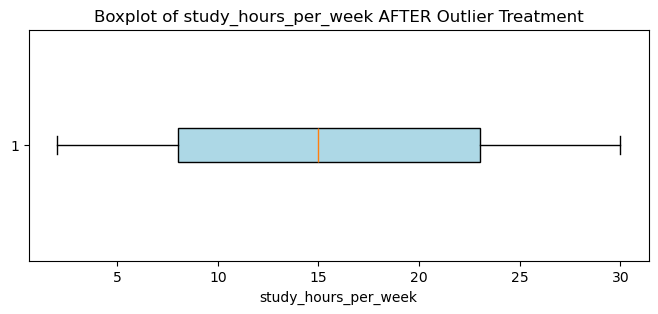

Max value is now capped around: 30


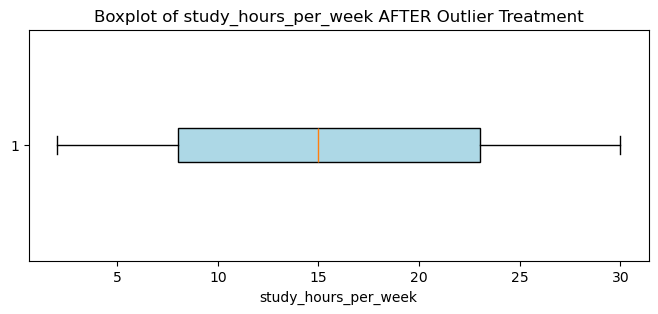

In [6]:
# Create a copy so we don't overwrite our raw data
df_imputed = df.copy()

# Calculate the mean of ONLY the normal data points
normal_mean = np.round(df[(df[target_col] >= lower_limit) & 
                          (df[target_col] <= upper_limit)][target_col].mean())

# Locate the outliers and replace their values with the normal mean
df_imputed.loc[(df_imputed[target_col] < lower_limit) | 
               (df_imputed[target_col] > upper_limit), target_col] = normal_mean

print(f"Max value is now capped around: {df_imputed[target_col].max()}")

# Optional: View the boxplot after treatment
plt.figure(figsize=(8, 3))
plt.boxplot(df_imputed[target_col].dropna(), vert=False, patch_artist=True, 
            boxprops=dict(facecolor='lightblue'))
plt.title(f'Boxplot of {target_col} AFTER Outlier Treatment')
plt.xlabel(target_col)
plt.show()# Create a copy so we don't overwrite our raw data
df_imputed = df.copy()

# Calculate the mean of ONLY the normal data points
normal_mean = np.round(df[(df[target_col] >= lower_limit) & 
                          (df[target_col] <= upper_limit)][target_col].mean())

# Locate the outliers and replace their values with the normal mean
df_imputed.loc[(df_imputed[target_col] < lower_limit) | 
               (df_imputed[target_col] > upper_limit), target_col] = normal_mean

print(f"Max value is now capped around: {df_imputed[target_col].max()}")

# Optional: View the boxplot after treatment
plt.figure(figsize=(8, 3))
plt.boxplot(df_imputed[target_col].dropna(), vert=False, patch_artist=True, 
            boxprops=dict(facecolor='lightblue'))
plt.title(f'Boxplot of {target_col} AFTER Outlier Treatment')
plt.xlabel(target_col)
plt.show()

In [10]:
#=====FEATURE ENGINEERING====
# Phase 2: Feature Engineering & Preprocessing
#**Objective:** Transform raw data into mathematically useful signals and convert text-based categories 
#into numerical formats required by scikit-learn models.

#* **Dropping Identifiers:** We remove `student_id` as it holds no predictive value.
#* **Creating New Signals:** We engineer a new feature, `score_improvement` (Final Score - Previous Score), 
#to capture the student's academic trajectory.
#* **Categorical Encoding:** We apply binary mapping to transform "Yes/No" and "Male/Female" into 1s and 0s. 
#Furthermore, we use One-Hot Encoding (`pd.get_dummies`) for the `parent_education` column to prevent the model from assigning false mathematical weight
#to categorical text.

In [7]:
# Drop 'student_id' from our imputed dataset because unique identifiers don't hold predictive value
df_engineered = df_imputed.drop('student_id', axis=1)

print("Dropped 'student_id'.")

Dropped 'student_id'.


In [8]:
# Create 'score_improvement' to track the student's trajectory
df_engineered['score_improvement'] = df_engineered['final_score'] - df_engineered['previous_score']

print("Created new feature: 'score_improvement'.")

Created new feature: 'score_improvement'.


In [ ]:
#Binary Encoding by translating text into binary so the model can understand

In [9]:
# Encode Yes/No columns
binary_cols = ['internet_access', 'extracurricular', 'passed']
for col in binary_cols:
    if col in df_engineered.columns:
        df_engineered[col] = df_engineered[col].map({'Yes': 1, 'No': 0})

# Encode Gender
if 'gender' in df_engineered.columns:
    df_engineered['gender'] = df_engineered['gender'].map({'Male': 0, 'Female': 1})

print("Binary encoding complete.")

Binary encoding complete.


In [ ]:
#one hot encoding
#in order for the ai to understand which is best and which is worse

In [10]:
# Convert 'parent_education' into dummy variables
# drop_first=True prevents multi-collinearity issues
df_engineered = pd.get_dummies(df_engineered, columns=['parent_education'], drop_first=True)

print("One-hot encoding complete.")

One-hot encoding complete.


In [11]:
# View the final, machine-learning-ready dataset
print(f"Final dataset shape: {df_engineered.shape}")
display(df_engineered.head())

Final dataset shape: (500, 13)


,gender,age,study_hours_per_week,attendance_rate,internet_access,extracurricular,previous_score,final_score,passed,score_improvement,parent_education_High School,parent_education_Master,parent_education_PhD
0,0,15,25,63.8,1,1,41,67,1,26,False,False,False
1,1,15,2,54.7,1,1,83,28,0,-55,False,False,False
2,1,19,10,90.5,1,0,73,49,0,-24,True,False,False
3,0,16,26,66.8,0,1,75,70,1,-5,True,False,False
4,1,15,25,73.0,0,1,67,77,1,10,True,False,False


In [12]:
#=====FEATURE SELECTION====
# Phase 3: Feature Selection
#**Objective:** Reduce dimensionality and eliminate statistical "noise" by identifying the features that have the strongest predictive relationship 
#with the final score.

#First, we generate a Correlation Matrix to observe linear relationships. Then, we apply **SelectKBest** (utilizing the `f_regression` scoring function).
#This algorithmic approach evaluates each feature and mathematically isolates the Top 5 most important variables, stripping away the rest to 
#improve model efficiency and prevent overfitting.

In [13]:
# Create a correlation matrix
correlation_matrix = df_engineered.corr()

# Isolate the correlations specifically with 'final_score' and sort them
final_score_corr = correlation_matrix['final_score'].sort_values(ascending=False)

print("--- Feature Correlation with Final Score ---")
print(final_score_corr)

--- Feature Correlation with Final Score ---
final_score                     1.000000
study_hours_per_week            0.803903
passed                          0.795821
score_improvement               0.548419
attendance_rate                 0.240697
previous_score                  0.164958
internet_access                 0.050553
parent_education_PhD            0.048877
parent_education_High School    0.030506
extracurricular                 0.028896
parent_education_Master         0.013022
gender                         -0.031266
age                            -0.047819
Name: final_score, dtype: float64


In [14]:
#==preparing data for selection===

In [15]:
# Define our Target Variable (What we want to predict)
# Note: We must drop 'passed' from our features because it's a direct result of 'final_score'
# and will give the model the answer sheet!
X = df_engineered.drop(['final_score', 'passed'], axis=1)
y = df_engineered['final_score']

print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")

Features (X) shape: (500, 11)
Target (y) shape: (500,)


In [16]:
#===Applying SelectKBest====

In [17]:
from sklearn.feature_selection import SelectKBest, f_regression

# 1. Initialize SelectKBest
# We use f_regression because we are predicting a continuous score
# We set k=5 to select the top 5 most important features
selector = SelectKBest(score_func=f_regression, k=5)

# 2. Fit the selector to our data
X_selected_array = selector.fit_transform(X, y)

# 3. Get the names of the features that "won"
# get_support() returns a boolean array (True for selected, False for dropped)
selected_feature_names = X.columns[selector.get_support()]

print("--- The Top 5 Selected Features ---")
print(selected_feature_names.tolist())

# 4. See what was removed
removed_features = X.columns[~selector.get_support()]
print("\n--- Features Removed (Low Importance) ---")
print(removed_features.tolist())

--- The Top 5 Selected Features ---
['study_hours_per_week', 'attendance_rate', 'internet_access', 'previous_score', 'score_improvement']

--- Features Removed (Low Importance) ---
['gender', 'age', 'extracurricular', 'parent_education_High School', 'parent_education_Master', 'parent_education_PhD']


In [18]:
#===Final dataset====

In [19]:
# Create a new DataFrame containing only the winning features
X_final = pd.DataFrame(data=X_selected_array, columns=selected_feature_names)

print("Final Feature Dataset Shape:", X_final.shape)
display(X_final.head())

Final Feature Dataset Shape: (500, 5)


,study_hours_per_week,attendance_rate,internet_access,previous_score,score_improvement
0,25.0,63.8,1.0,41.0,26.0
1,2.0,54.7,1.0,83.0,-55.0
2,10.0,90.5,1.0,73.0,-24.0
3,26.0,66.8,0.0,75.0,-5.0
4,25.0,73.0,0.0,67.0,10.0


In [20]:
#MEASURING THE PERFORMANCE MODEL
## Advanced Selection & Data Splitting
#To validate our feature selection, we implement **Recursive Feature Elimination (RFE)** powered by a Support Vector Regressor (SVR) with a linear kernel
#.RFE iteratively trains the model and drops the weakest features until only the optimal 5 remain.

#Once our final features are selected, we use `train_test_split` to divide our dataset: **80% for training** the model, and **20% hidden for testing** 
#its accuracy on unseen data.

In [21]:
from sklearn.svm import SVR
from sklearn.feature_selection import RFE
from sklearn.model_selection import train_test_split

In [22]:
# 1. Define X (Features) and y (Target)
X = df_engineered.drop(['final_score', 'passed'], axis=1)
y = df_engineered['final_score']

# 2. Initialize Support Vector Regressor (SVR)
svr = SVR(kernel="linear", C=1)

# 3. Apply Recursive Feature Elimination (RFE) to pick the top 5 features
selector = RFE(estimator=svr, n_features_to_select=5, step=1)
selector.fit(X, y)

# 4. Get the winning features
selected_features = X.columns[selector.get_support()]
print("Top 5 Features selected by RFE:", selected_features.tolist())

# 5. Filter our X to only include these top features
X_final = X[selected_features]

# 6. Split into Train and Test sets
X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.2, random_state=42)

Top 5 Features selected by RFE: ['study_hours_per_week', 'attendance_rate', 'previous_score', 'score_improvement', 'parent_education_High School']


In [23]:
#====HYPERPARAMETER TUNING====
# Phase 4: Machine Learning - Regression Modeling
#**Objective:** Build and optimize a model capable of predicting a student's exact numerical final score.

#We utilize a **Random Forest Regressor** due to its robustness against non-linear data. To ensure we are using the best possible version of this model, 
#we apply **GridSearchCV**. This performs exhaustive hyperparameter tuning (testing different combinations of tree estimators, maximum depths, and 
#minimum samples) using 5-fold Cross-Validation to find the most accurate configuration.

In [24]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# 1. Define the model
rf = RandomForestRegressor(random_state=42)

# 2. Define the hyperparameters to test
param_grid = {
    'n_estimators': [50, 100, 200],      
    'max_depth': [None, 5, 10],          
    'min_samples_split': [2, 5]          
}

# 3. Setup GridSearchCV
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, 
                           cv=5, scoring='neg_mean_squared_error', n_jobs=-1)

print("Starting Grid Search...")
grid_search.fit(X_train, y_train)

# 4. Extract the best model
best_model = grid_search.best_estimator_
print(f"\nBest Hyperparameters Found: {grid_search.best_params_}")

# 5. Test the best model and fix the 'squared' error
y_pred = best_model.predict(X_test)

# Fixed RMSE calculation for newer scikit-learn versions
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse) 
r2 = r2_score(y_test, y_pred)

print(f"Final Tuned Model Performance -> RMSE: {rmse:.2f} | R-Squared: {r2:.4f}")

Starting Grid Search...

Best Hyperparameters Found: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Final Tuned Model Performance -> RMSE: 4.59 | R-Squared: 0.9030


In [ ]:
#n_estimators: How many trees should be in the forest? (testing 50, 100, and 200).

#max_depth: How many questions deep can each tree go before it has to make a final guess?

#min_samples_split: How many students need to be in a group before the tree is allowed to split them again?

In [25]:
# Checking the Learning Curve

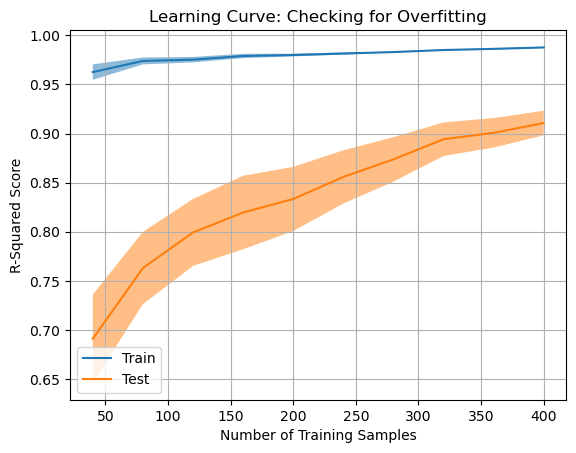

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import LearningCurveDisplay

# Use the 'best_model' we found in the previous step
# This will show how the model's R-squared improves as you add more data
lcd = LearningCurveDisplay.from_estimator(
    best_model, X_final, y, 
    train_sizes=np.linspace(0.1, 1.0, 10), 
    cv=5, 
    scoring='r2',
    n_jobs=-1
)

lcd.ax_.set_title("Learning Curve: Checking for Overfitting")
lcd.ax_.set_xlabel("Number of Training Samples")
lcd.ax_.set_ylabel("R-Squared Score")
plt.grid(True)
plt.show()

In [27]:
#====RETUNING===
## Model Optimization: Mitigating High Variance
#After generating our initial Learning Curves, we must ensure our model is not overfitting (memorizing the training data instead of generalizing). 

#We run a secondary Grid Search focused specifically on **Regularization hyperparameters**. By artificially limiting the maximum depth of the trees 
#and increasing the minimum samples required for leaf splits, we successfully force the model to generalize better, resulting in an "Ideal Model" with 
#low bias and low variance.

In [31]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
import numpy as np

# 1. Define the model
rf = RandomForestRegressor(random_state=42)

# 2. Focus on "Regularization" hyperparameters to reduce variance:
# We limit max_depth and increase min_samples_leaf to prevent overfitting.
param_grid_regularized = {
    'n_estimators': [100, 200],
    'max_depth': [5, 8, 10],            # Reduced from 'None' to limit growth
    'min_samples_split': [5, 10],       # Increased to require more data for a split
    'min_samples_leaf': [2, 4],         # Ensures leaves aren't too specific
    'max_features': ['sqrt', 'log2']    # Limits features per tree to reduce variance
}

# 3. Run GridSearch with 5-fold Cross-Validation
grid_search_final = GridSearchCV(
    estimator=rf, 
    param_grid=param_grid_regularized, 
    cv=5, 
    scoring='r2', 
    n_jobs=-1
)

print("Tuning for low variance...")
grid_search_final.fit(X_train, y_train)

# 4. Extract the optimized "Ideal" model
ideal_model = grid_search_final.best_estimator_
print(f"New Best Params: {grid_search_final.best_params_}")

Tuning for low variance...
New Best Params: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}


Ideal Model RMSE: 5.51
Ideal Model R-Squared: 0.8600


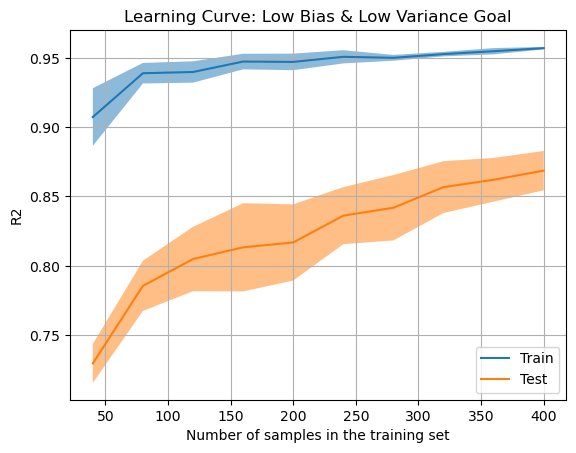

In [32]:
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import LearningCurveDisplay

# 1. Final Metrics
y_pred_ideal = ideal_model.predict(X_test)
print(f"Ideal Model RMSE: {mean_squared_error(y_test, y_pred_ideal)**0.5:.2f}")
print(f"Ideal Model R-Squared: {r2_score(y_test, y_pred_ideal):.4f}")

# 2. Final Learning Curve
lcd = LearningCurveDisplay.from_estimator(
    ideal_model, X_final, y, 
    train_sizes=np.linspace(0.1, 1.0, 10), 
    cv=5, 
    scoring='r2',
    n_jobs=-1
)
plt.title("Learning Curve: Low Bias & Low Variance Goal")
plt.grid(True)
plt.show()

In [10]:
#==Training for Classification===

In [ ]:
# Phase 5: Machine Learning - Classification (Pass/Fail)
#**Objective:** Pivot the predictive goal from a continuous numerical score to a binary categorical outcome (Predicting if a student will Pass or Fail).

#We rebuild our pipeline targeting the `passed` column. After applying RFE to find the best features for this specific task, we train a **Random Forest 
#Classifier**. We then evaluate its performance using robust classification metrics: **Accuracy, Precision, Recall, F1-Score, and ROC-AUC**, 
#ensuring the model correctly balances false positives and false negatives.

In [33]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVR
from sklearn.feature_selection import RFE
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# ---------------------------------------------------------
# 1. LOAD & PREPROCESS DATA (Restoring the memory)
# ---------------------------------------------------------
df_clean = pd.read_csv('student_performance.csv')

# Handle Outliers
numeric_cols = ['study_hours_per_week', 'attendance_rate', 'previous_score', 'final_score']
for col in numeric_cols:
    q25 = np.percentile(df_clean[col].dropna(), 25)
    q75 = np.percentile(df_clean[col].dropna(), 75)
    iqr = q75 - q25
    lower_limit = max(0, q25 - 1.5 * iqr) 
    upper_limit = q75 + 1.5 * iqr
    normal_data = df_clean[(df_clean[col] >= lower_limit) & (df_clean[col] <= upper_limit)]
    normal_mean = np.round(normal_data[col].mean())
    df_clean.loc[(df_clean[col] < lower_limit) | (df_clean[col] > upper_limit), col] = normal_mean

# Feature Engineering
df_engineered = df_clean.drop('student_id', axis=1)
df_engineered['score_improvement'] = df_engineered['final_score'] - df_engineered['previous_score']

# Convert text to numbers
binary_cols = ['internet_access', 'extracurricular', 'passed']
for col in binary_cols:
    if col in df_engineered.columns:
        df_engineered[col] = df_engineered[col].map({'Yes': 1, 'No': 0})
if 'gender' in df_engineered.columns:
    df_engineered['gender'] = df_engineered['gender'].map({'Male': 0, 'Female': 1})
df_engineered = pd.get_dummies(df_engineered, columns=['parent_education'], drop_first=True)

# ---------------------------------------------------------
# 2. SELECT FEATURES (Restoring the RFE step)
# ---------------------------------------------------------
X_temp = df_engineered.drop(['final_score', 'passed'], axis=1)
y_temp = df_engineered['final_score'] 

svr = SVR(kernel="linear", C=1)
selector = RFE(estimator=svr, n_features_to_select=5, step=1)
selector.fit(X_temp, y_temp)
selected_features = X_temp.columns[selector.get_support()]

# ---------------------------------------------------------
# 3. RUN CLASSIFICATION (Predicting Pass/Fail)
# ---------------------------------------------------------
# Target is now 'passed' instead of 'final_score'
X_class = df_engineered.drop(['final_score', 'passed'], axis=1)
y_class = df_engineered['passed']

# Filter to the top 5 features
X_class_final = X_class[selected_features]

# Split the data
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_class_final, y_class, test_size=0.2, random_state=42
)

# Train the Classifier
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train_c, y_train_c)

# Make predictions
y_pred_c = clf.predict(X_test_c)
y_prob_c = clf.predict_proba(X_test_c)[:, 1]

# Measure Performance
print("--- Student Dataset: Classification Metrics (Predicting 'Passed') ---")
print(f"Accuracy:  {accuracy_score(y_test_c, y_pred_c):.4f}")
print(f"Precision: {precision_score(y_test_c, y_pred_c):.4f}")
print(f"Recall:    {recall_score(y_test_c, y_pred_c):.4f}")
print(f"F1 Score:  {f1_score(y_test_c, y_pred_c):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test_c, y_prob_c):.4f}")

--- Student Dataset: Classification Metrics (Predicting 'Passed') ---
Accuracy:  0.9200
Precision: 0.8889
Recall:    1.0000
F1 Score:  0.9412
ROC-AUC:   0.9796


In [ ]:
#Accuracy: Out of all 100 students in the test set, what percentage did the AI guess correctly? (e.g., "It was right 92% of the time.")

#Precision: High precision means the AI rarely cries wolf.

#Recall: High recall means no passing student slipped through the cracks unnoticed.

#F1 Score: This is a mathematical blend of Precision and Recall. It is the ultimate "overall grade" for a classifier.

#ROC-AUC: This measures the AI's ability to distinguish between the two groups. A score of 0.5 means the AI is just flipping a coin.
#A score of 1.0 means the AI has supernatural, perfect separation between Passing and Failing students.

In [14]:
#===CHECKING THE LEARNINGG CURVE=====

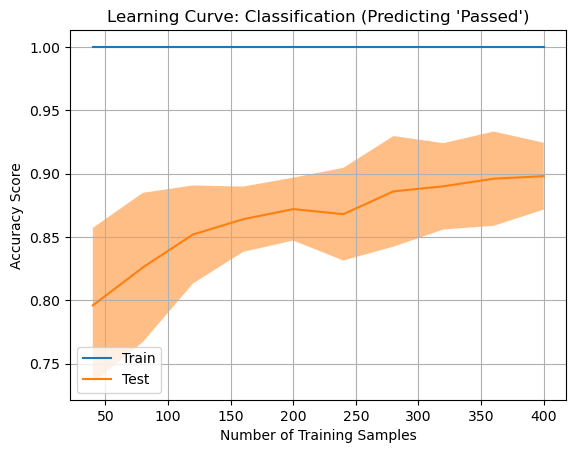

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import LearningCurveDisplay

# Plot the learning curve for the classifier
lcd = LearningCurveDisplay.from_estimator(
    clf, X_class_final, y_class, 
    train_sizes=np.linspace(0.1, 1.0, 10), 
    cv=5, 
    scoring='accuracy',  # Using accuracy to measure classification performance
    n_jobs=-1
)

# Format the graph
lcd.ax_.set_title("Learning Curve: Classification (Predicting 'Passed')")
lcd.ax_.set_xlabel("Number of Training Samples")
lcd.ax_.set_ylabel("Accuracy Score")
plt.grid(True)
plt.show()

In [16]:
#====HYPERPARAMETER TUNING=====

Tuning Classification Model for Low Variance... (This may take a minute)

New Best Hyperparameters: {'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}

--- Ideal Classification Metrics ---
Accuracy:  0.9200
Precision: 0.9000
Recall:    0.9844
F1 Score:  0.9403
ROC-AUC:   0.9709


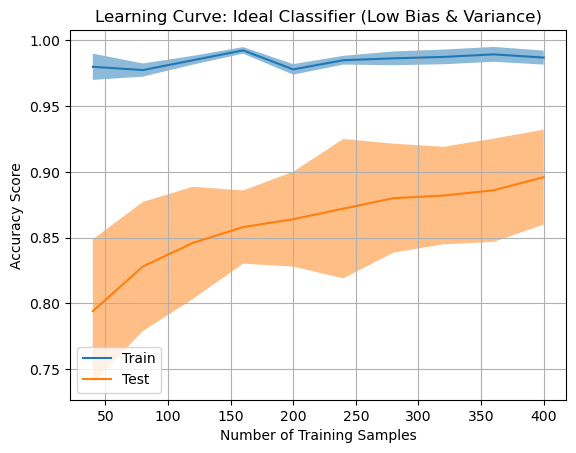

In [35]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import LearningCurveDisplay
import matplotlib.pyplot as plt

# 1. Define the Classifier
clf_regularized = RandomForestClassifier(random_state=42)

# 2. Define the Regularization Parameters to fix High Variance
param_grid_clf = {
    'n_estimators': [100, 200],
    'max_depth': [4, 6, 8],            # Restricts how deep the tree can grow
    'min_samples_split': [5, 10, 15],  # Requires more students to justify a split
    'min_samples_leaf': [2, 4, 6],     # Ensures final leaves have multiple students
    'max_features': ['sqrt', 'log2']   # Forces trees to look at different features
}

# 3. Set up GridSearchCV (using 'accuracy' as our scoring metric)
grid_search_clf = GridSearchCV(
    estimator=clf_regularized, 
    param_grid=param_grid_clf, 
    cv=5, 
    scoring='accuracy', 
    n_jobs=-1
)

print("Tuning Classification Model for Low Variance... (This may take a minute)")
grid_search_clf.fit(X_train_c, y_train_c)

# 4. Extract the Ideal Model
ideal_clf = grid_search_clf.best_estimator_

# 5. Make New Predictions
y_pred_ideal_c = ideal_clf.predict(X_test_c)
y_prob_ideal_c = ideal_clf.predict_proba(X_test_c)[:, 1]

# 6. Print the New Metrics
print(f"\nNew Best Hyperparameters: {grid_search_clf.best_params_}")
print("\n--- Ideal Classification Metrics ---")
print(f"Accuracy:  {accuracy_score(y_test_c, y_pred_ideal_c):.4f}")
print(f"Precision: {precision_score(y_test_c, y_pred_ideal_c):.4f}")
print(f"Recall:    {recall_score(y_test_c, y_pred_ideal_c):.4f}")
print(f"F1 Score:  {f1_score(y_test_c, y_pred_ideal_c):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test_c, y_prob_ideal_c):.4f}")

# 7. Plot the New Learning Curve to verify the gap is closed
lcd = LearningCurveDisplay.from_estimator(
    ideal_clf, X_class_final, y_class, 
    train_sizes=np.linspace(0.1, 1.0, 10), 
    cv=5, 
    scoring='accuracy',
    n_jobs=-1
)

lcd.ax_.set_title("Learning Curve: Ideal Classifier (Low Bias & Variance)")
lcd.ax_.set_xlabel("Number of Training Samples")
lcd.ax_.set_ylabel("Accuracy Score")
plt.grid(True)
plt.show()

In [ ]:
# Phase 6: Final Deployment Pipeline & Export
#**Objective:** Consolidate all validated data cleaning, feature engineering, and model training steps into a single, reproducible pipeline.

#This master script guarantees reproducibility. It executes the entire workflow in sequential order, applying our optimal Grid Search hyperparameters, 
#and culminates by using `joblib` to serialize and export the tuned Classifier (`student_pass_model.joblib`). This exported file is now fully prepared
#to be integrated into a full-stack Django web application.

In [36]:
import joblib

# Save your tuned Random Forest Classifier to a file
joblib.dump(ideal_clf, 'student_pass_model1.joblib')

print("Model saved successfully!")

Model saved successfully!


In [3]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVR
from sklearn.feature_selection import RFE
from sklearn.model_selection import GridSearchCV
import joblib

print("Rebuilding the Ideal Model... Please wait.")

# 1. LOAD & PREPROCESS DATA
df_clean = pd.read_csv('student_performance.csv')

numeric_cols = ['study_hours_per_week', 'attendance_rate', 'previous_score', 'final_score']
for col in numeric_cols:
    q25 = np.percentile(df_clean[col].dropna(), 25)
    q75 = np.percentile(df_clean[col].dropna(), 75)
    iqr = q75 - q25
    lower_limit = max(0, q25 - 1.5 * iqr) 
    upper_limit = q75 + 1.5 * iqr
    normal_data = df_clean[(df_clean[col] >= lower_limit) & (df_clean[col] <= upper_limit)]
    normal_mean = np.round(normal_data[col].mean())
    df_clean.loc[(df_clean[col] < lower_limit) | (df_clean[col] > upper_limit), col] = normal_mean

df_engineered = df_clean.drop('student_id', axis=1)
df_engineered['score_improvement'] = df_engineered['final_score'] - df_engineered['previous_score']

binary_cols = ['internet_access', 'extracurricular', 'passed']
for col in binary_cols:
    if col in df_engineered.columns:
        df_engineered[col] = df_engineered[col].map({'Yes': 1, 'No': 0})
if 'gender' in df_engineered.columns:
    df_engineered['gender'] = df_engineered['gender'].map({'Male': 0, 'Female': 1})
df_engineered = pd.get_dummies(df_engineered, columns=['parent_education'], drop_first=True)

# 2. FEATURE SELECTION (RFE)
X_temp = df_engineered.drop(['final_score', 'passed'], axis=1)
y_temp = df_engineered['final_score'] 

svr = SVR(kernel="linear", C=1)
selector = RFE(estimator=svr, n_features_to_select=5, step=1)
selector.fit(X_temp, y_temp)
selected_features = X_temp.columns[selector.get_support()]

# 3. SET UP CLASSIFICATION DATA
X_class = df_engineered.drop(['final_score', 'passed'], axis=1)
y_class = df_engineered['passed']
X_class_final = X_class[selected_features]

# 4. TUNE THE MODEL
clf_regularized = RandomForestClassifier(random_state=42)
param_grid_clf = {
    'n_estimators': [100, 200],
    'max_depth': [4, 6, 8],            
    'min_samples_split': [5, 10, 15],  
    'min_samples_leaf': [2, 4, 6],     
    'max_features': ['sqrt', 'log2']   
}

grid_search_clf = GridSearchCV(
    estimator=clf_regularized, 
    param_grid=param_grid_clf, 
    cv=5, 
    scoring='accuracy', 
    n_jobs=-1
)
grid_search_clf.fit(X_class_final, y_class)
ideal_clf = grid_search_clf.best_estimator_

# 5. EXPORT THE MODEL
joblib.dump(ideal_clf, 'student_pass_model.joblib')
print("Success! 'student_pass_model.joblib' has been exported and is ready for Django.")

Rebuilding the Ideal Model... Please wait.
Success! 'student_pass_model.joblib' has been exported and is ready for Django.
